In [ ]:
!pip install google-play-scraper
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install textblob
!pip install nltk
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.1 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import reviews_all, Sort

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

import re

In [ ]:
from google_play_scraper import reviews

result, continuation_token = reviews(
    'com.pinterest',
    lang='en',
    country='us',
    count=2000
)

pinterest_reviews = result

In [ ]:
df = pd.DataFrame(np.array(pinterest_reviews),columns=['review'])
df = df.join(pd.DataFrame(df.pop('review').tolist()))

In [ ]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,1d52a867-51dc-4c69-8288-a149996727c7,Chloe Guitty Masrour,https://play-lh.googleusercontent.com/a-/ALV-U...,The app has become simply unusable. More adds ...,2,2,14.8.0,2026-03-10 01:22:06,None,None,14.8.0
1,d3f2b6b4-ecf7-42bf-ae1b-121b135b0631,Serenity,https://play-lh.googleusercontent.com/a-/ALV-U...,love it but it won't let me crop out pictures ...,5,0,None,2026-03-10 01:10:19,None,None,None
2,05c0f8de-597f-499b-80f0-aefeb0b98f10,Karol Duncan,https://play-lh.googleusercontent.com/a-/ALV-U...,Have absolutely everything you ever want on Pi...,5,0,14.8.0,2026-03-10 00:55:35,None,None,14.8.0
3,2b5d5703-fb42-440f-8713-099327a06fe7,lokiii,https://play-lh.googleusercontent.com/a-/ALV-U...,Hate to see an app like this ruined both with ...,1,0,14.8.0,2026-03-10 00:33:37,None,None,14.8.0
4,5236f6b0-b0fc-4689-9576-ffc764a12450,game mirip ubi,https://play-lh.googleusercontent.com/a/ACg8oc...,I hate your stupid age verification now i cant...,2,0,14.9.0,2026-03-10 00:28:35,None,None,14.9.0


In [ ]:
df = df[['content','score','at']]
df.head()

,content,score,at
0,The app has become simply unusable. More adds ...,2,2026-03-10 01:22:06
1,love it but it won't let me crop out pictures ...,5,2026-03-10 01:10:19
2,Have absolutely everything you ever want on Pi...,5,2026-03-10 00:55:35
3,Hate to see an app like this ruined both with ...,1,2026-03-10 00:33:37
4,I hate your stupid age verification now i cant...,2,2026-03-10 00:28:35


In [ ]:
df.columns = ['review','rating','date']
df.head()

,review,rating,date
0,The app has become simply unusable. More adds ...,2,2026-03-10 01:22:06
1,love it but it won't let me crop out pictures ...,5,2026-03-10 01:10:19
2,Have absolutely everything you ever want on Pi...,5,2026-03-10 00:55:35
3,Hate to see an app like this ruined both with ...,1,2026-03-10 00:33:37
4,I hate your stupid age verification now i cant...,2,2026-03-10 00:28:35


In [ ]:
len(df)

2000

In [ ]:
df.to_csv("pinterest_reviews.csv", index=False)

In [ ]:
df['rating'].value_counts()

,count
rating,
5,1405
1,271
4,169
3,80
2,75


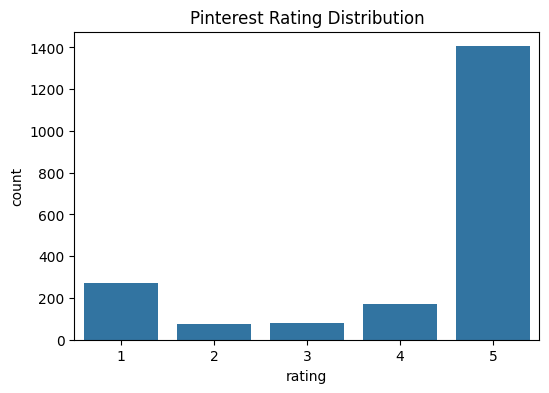

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='rating', data=df)

plt.title("Pinterest Rating Distribution")

plt.show()

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

In [ ]:
df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review,rating,date,clean_review
0,The app has become simply unusable. More adds ...,2,2026-03-10 01:22:06,the app has become simply unusable more adds a...
1,love it but it won't let me crop out pictures ...,5,2026-03-10 01:10:19,love it but it wont let me crop out pictures a...
2,Have absolutely everything you ever want on Pi...,5,2026-03-10 00:55:35,have absolutely everything you ever want on pi...
3,Hate to see an app like this ruined both with ...,1,2026-03-10 00:33:37,hate to see an app like this ruined both with ...
4,I hate your stupid age verification now i cant...,2,2026-03-10 00:28:35,i hate your stupid age verification now i cant...


In [ ]:
def get_polarity(text):

    analysis = TextBlob(text)

    return analysis.sentiment.polarity

In [ ]:
df['polarity'] = df['clean_review'].apply(get_polarity)

In [ ]:
def sentiment_label(score):

    if score > 0:
        return "Positive"

    elif score == 0:
        return "Neutral"

    else:
        return "Negative"

In [ ]:
df['sentiment'] = df['polarity'].apply(sentiment_label)

df.head()

,review,rating,date,clean_review,polarity,sentiment
0,The app has become simply unusable. More adds ...,2,2026-03-10 01:22:06,the app has become simply unusable more adds a...,-0.083333,Negative
1,love it but it won't let me crop out pictures ...,5,2026-03-10 01:10:19,love it but it wont let me crop out pictures a...,0.500000,Positive
2,Have absolutely everything you ever want on Pi...,5,2026-03-10 00:55:35,have absolutely everything you ever want on pi...,0.350000,Positive
3,Hate to see an app like this ruined both with ...,1,2026-03-10 00:33:37,hate to see an app like this ruined both with ...,-0.200000,Negative
4,I hate your stupid age verification now i cant...,2,2026-03-10 00:28:35,i hate your stupid age verification now i cant...,-0.766667,Negative


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,1470
Neutral,375
Negative,155


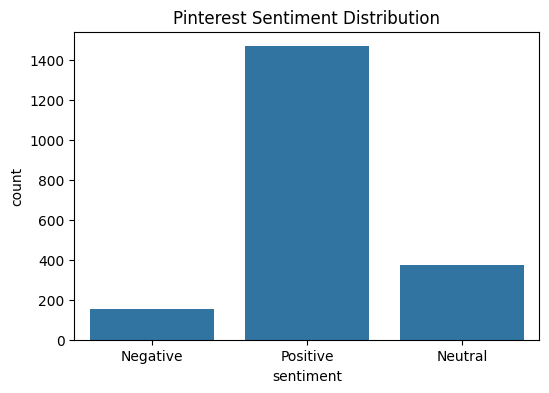

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=df)

plt.title("Pinterest Sentiment Distribution")

plt.show()

In [ ]:
from wordcloud import WordCloud

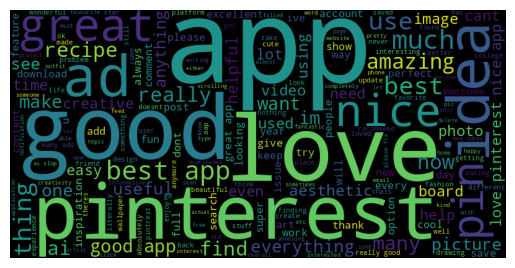

In [ ]:
positive = df[df['sentiment']=="Positive"]

text = " ".join(positive['clean_review'])

wordcloud = WordCloud(width=800,height=400).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [ ]:
df.to_csv("pinterest_sentiment.csv", index=False)

In [ ]:
from google.colab import files
files.download("pinterest_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("pinterest_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.head()

,review,rating,date,clean_review,polarity,sentiment
0,The app has become simply unusable. More adds ...,2,2026-03-10 01:22:06,the app has become simply unusable more adds a...,-0.083333,Negative
1,love it but it won't let me crop out pictures ...,5,2026-03-10 01:10:19,love it but it wont let me crop out pictures a...,0.500000,Positive
2,Have absolutely everything you ever want on Pi...,5,2026-03-10 00:55:35,have absolutely everything you ever want on pi...,0.350000,Positive
3,Hate to see an app like this ruined both with ...,1,2026-03-10 00:33:37,hate to see an app like this ruined both with ...,-0.200000,Negative
4,I hate your stupid age verification now i cant...,2,2026-03-10 00:28:35,i hate your stupid age verification now i cant...,-0.766667,Negative


In [ ]:
def sentiment_rating(score):

    if score >= 4:
        return "Positive"

    elif score == 3:
        return "Neutral"

    else:
        return "Negative"

In [ ]:
df['sentiment_rating'] = df['rating'].apply(sentiment_rating)

In [ ]:
df.head()

,review,rating,date,clean_review,polarity,sentiment,sentiment_rating
0,The app has become simply unusable. More adds ...,2,2026-03-10 01:22:06,the app has become simply unusable more adds a...,-0.083333,Negative,Negative
1,love it but it won't let me crop out pictures ...,5,2026-03-10 01:10:19,love it but it wont let me crop out pictures a...,0.500000,Positive,Positive
2,Have absolutely everything you ever want on Pi...,5,2026-03-10 00:55:35,have absolutely everything you ever want on pi...,0.350000,Positive,Positive
3,Hate to see an app like this ruined both with ...,1,2026-03-10 00:33:37,hate to see an app like this ruined both with ...,-0.200000,Negative,Negative
4,I hate your stupid age verification now i cant...,2,2026-03-10 00:28:35,i hate your stupid age verification now i cant...,-0.766667,Negative,Negative


In [ ]:
df_final = df[['review','rating','date','sentiment_rating']]
df_final.head()

,review,rating,date,sentiment_rating
0,The app has become simply unusable. More adds ...,2,2026-03-10 01:22:06,Negative
1,love it but it won't let me crop out pictures ...,5,2026-03-10 01:10:19,Positive
2,Have absolutely everything you ever want on Pi...,5,2026-03-10 00:55:35,Positive
3,Hate to see an app like this ruined both with ...,1,2026-03-10 00:33:37,Negative
4,I hate your stupid age verification now i cant...,2,2026-03-10 00:28:35,Negative


In [ ]:
df_final = df_final.head(2000)

In [ ]:
df_final.to_excel("pinterest_sentiment_sheet.xlsx", index=False)

In [ ]:
from google.colab import files
files.download("pinterest_sentiment_sheet.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
from collections import Counter

In [5]:
from google.colab import files
files.upload()

Saving pinterest_reviews.csv to pinterest_reviews (2).csv


{'pinterest_reviews (2).csv': b'review,rating,date\nThe app has become simply unusable. More adds apere than actual pins! Half of the time i have to decipher if it is a post i can save or a publicity. Disappointed.,2,2026-03-10 01:22:06\nlove it but it won\'t let me crop out pictures anymore,5,2026-03-10 01:10:19\nHave absolutely everything you ever want on Pinterest!! Love it all!@,5,2026-03-10 00:55:35\nHate to see an app like this ruined both with AI slop that the filter doesn\'t properly work on and improper management that caused many accounts to be banned for no reason. I\'ll be deleting my account and uninstalling ASAP.,1,2026-03-10 00:33:37\nI hate your stupid age verification now i cant join because how bad it is,2,2026-03-10 00:28:35\nany time i download the app it says put your date off birth I will put it it will say u can not open this account,1,2026-03-10 00:22:22\n"very good posting,like quilting,knitting,crochet items.",5,2026-03-09 23:38:37\noptional,3,2026-03-09 23:32

In [9]:
df = pd.read_csv("pinterest_reviews.csv")

In [10]:
df.columns

Index(['review', 'rating', 'date'], dtype='object')

In [11]:
def sentiment_rating(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment_rating'] = df['rating'].apply(sentiment_rating)

In [12]:
df_positive = df[df['sentiment_rating'] == 'Positive']
df_negative = df[df['sentiment_rating'] == 'Negative']

In [13]:
text_positive = " ".join(df_positive['review'].astype(str))

In [14]:
text_negative = " ".join(df_negative['review'].astype(str))

In [15]:
words_positive = text_positive.lower().split()
words_negative = text_negative.lower().split()

In [16]:
bow_positive = Counter(words_positive)
bow_negative = Counter(words_negative)

In [17]:
bow_positive.most_common(20)

[('i', 605),
 ('app', 526),
 ('and', 501),
 ('it', 362),
 ('this', 337),
 ('the', 322),
 ('to', 302),
 ('is', 301),
 ('love', 290),
 ('good', 276),
 ('for', 262),
 ('very', 234),
 ('a', 219),
 ('so', 176),
 ('my', 167),
 ('best', 161),
 ('pinterest', 157),
 ("it's", 145),
 ('you', 144),
 ('of', 142)]

In [18]:
bow_negative.most_common(20)

[('the', 332),
 ('i', 264),
 ('to', 250),
 ('and', 249),
 ('it', 181),
 ('is', 141),
 ('of', 131),
 ('a', 129),
 ('app', 125),
 ('my', 112),
 ('this', 101),
 ('ads', 97),
 ('you', 92),
 ('for', 90),
 ('ai', 87),
 ('that', 79),
 ('not', 79),
 ('but', 72),
 ('on', 71),
 ("it's", 70)]

In [19]:
df_bow_positive = pd.DataFrame(bow_positive.most_common(20), columns=['word','count'])
df_bow_negative = pd.DataFrame(bow_negative.most_common(20), columns=['word','count'])

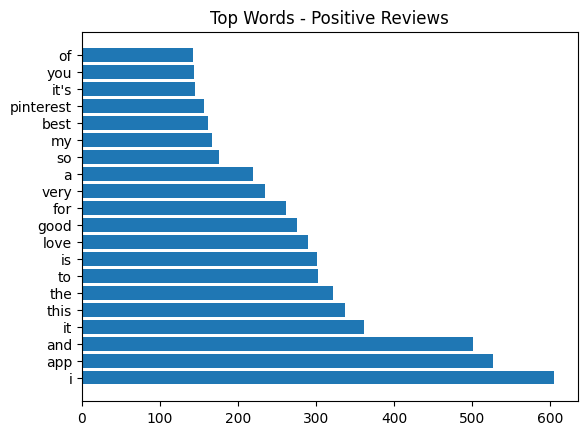

In [20]:
import matplotlib.pyplot as plt

plt.figure()

plt.barh(df_bow_positive['word'], df_bow_positive['count'])

plt.title("Top Words - Positive Reviews")

plt.show()

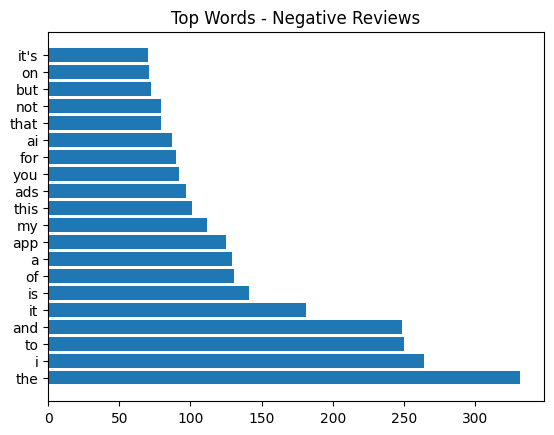

In [21]:
plt.figure()

plt.barh(df_bow_negative['word'], df_bow_negative['count'])

plt.title("Top Words - Negative Reviews")

plt.show()